# Task 2: Predict Future Stock Prices (Short-Term)

## Objective
The goal of this task is to predict the next day's closing price of a selected stock using historical stock data. We will use features such as Open, High, Low, and Volume. Linear Regression Model applied to make predictions.

## Dataset
- Source: Yahoo Finance (fetched using the `yfinance` Python library)
- Features used: Open, High, Low, Volume
- Target: Close price (shifted by one day to predict the next day)

## Expected Outcome
- Predict next day closing price accurately
- Visual comparison of actual vs predicted closing prices


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline


## Step 1: Load Historical Stock Data
We will fetch Tesla (TSLA) stock data from Yahoo Finance from January 2023 to present.


In [16]:
stock_symbol = 'TSLA'
data = yf.download(stock_symbol, start='2023-01-01', end='2025-11-24', auto_adjust=True)
data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2023-01-03,108.099998,118.800003,104.639999,118.470001,231402800
2023-01-04,113.639999,114.589996,107.519997,109.110001,180389000
2023-01-05,110.339996,111.750000,107.160004,110.510002,157986300
2023-01-06,113.059998,114.389999,101.809998,103.000000,220911100
2023-01-09,119.769997,123.519997,117.110001,118.959999,190284000


## Step 2: Feature Selection
We will use 'Open', 'High', 'Low', 'Volume' to predict the next day's 'Close' price.


In [9]:
features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

X = data[features]
y = data[target]

# Shift target by -1 to predict next day's Close
y = y.shift(-1)
X = X[:-1]
y = y[:-1]


## Step 3: Split Data into Training and Testing Sets
We will use 80% of data for training and 20% for testing. Shuffle is set to False to maintain chronological/time order.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


## Step 4: Train Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 5: Make Predictions
We will predict the next day's Close price by using Linear Regression Model.


In [12]:
lr_pred = lr_model.predict(X_test)
print(lr_pred)

[[280.75665363]
 [286.86287503]
 [276.37110041]
 [288.4736187 ]
 [288.76095658]
 [276.32879515]
 [275.07851091]
 [272.54831292]
 [287.49480913]
 [303.75066379]
 [313.14016396]
 [331.4738089 ]
 [343.55430521]
 [339.5795598 ]
 [346.39320278]
 [338.37827403]
 [347.91262989]
 [336.05979567]
 [343.16841594]
 [337.34678479]
 [359.8904782 ]
 [356.44989799]
 [358.44445163]
 [353.09952565]
 [337.90808226]
 [349.8760697 ]
 [330.3177292 ]
 [286.04109229]
 [298.25880971]
 [302.35324823]
 [321.88101425]
 [325.0932494 ]
 [325.15963675]
 [328.62671331]
 [326.94748086]
 [317.07658028]
 [324.90522512]
 [322.69775907]
 [352.10938744]
 [342.66293931]
 [324.38785018]
 [328.07036126]
 [321.97099013]
 [320.94194452]
 [300.27485079]
 [308.56549899]
 [313.06126401]
 [293.05906106]
 [300.2051981 ]
 [295.76772209]
 [308.0690257 ]
 [310.37059205]
 [316.7522036 ]
 [312.65529283]
 [320.71748252]
 [318.21938933]
 [328.1887275 ]
 [330.20298706]
 [326.79301157]
 [332.47663524]
 [302.34230748]
 [320.17829298]
 [325.49

## Step 6: Evaluate Model
Calculate Mean Squared Error (MSE) to measure prediction accuracy.


In [13]:
lr_mse = mean_squared_error(y_test, lr_pred)
print(f"Linear Regression MSE: {lr_mse}")


Linear Regression MSE: 154.8388187478753


## Step 7: Plot Actual vs Predicted Closing Prices
This helps to visually compare how well model predicts stock prices.


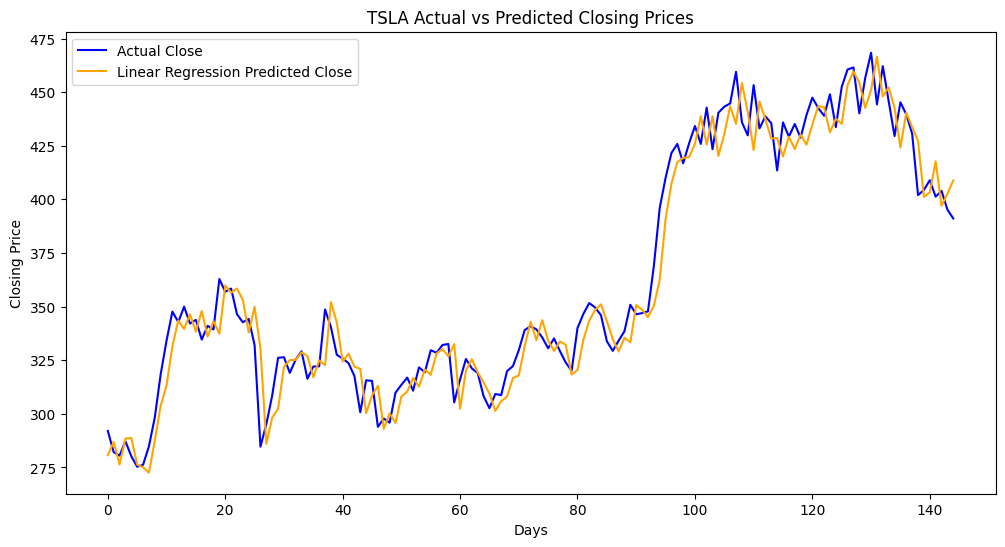

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close', color='blue')
plt.plot(lr_pred, label='Linear Regression Predicted Close', color='orange')
plt.title(f"{stock_symbol} Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()


## Final Insights
- Linear Regression gives a basic understanding of stock price movement.
- MSE values indicate how close predictions are to actual prices.
- To improve performance, advanced features like moving averages and technical indicators can be added.
